                                         学术领域                        主导机构  \
0        Advanced Causal Inference Techniques          Harvard University   
1         Bayesian Methods and Mixture Models             Duke University   
2     Advanced Statistical Methods and Models         Columbia University   
3      Statistical Methods in Clinical Trials  University of Pennsylvania   
4  Statistical Methods and Bayesian Inference             Duke University   
5      Financial Risk and Volatility Modeling      Ruhr University Bochum   
6            Random Matrices and Applications        Princeton University   
7         Complex Network Analysis Techniques  Carnegie Mellon University   
8       Markov Chains and Monte Carlo Methods       University of Warwick   
9   Sparse and Compressive Sensing Techniques        Princeton University   

   领域H指数  
0     28  
1     15  
2      8  
3     11  
4      8  
5      7  
6     12  
7     11  
8     13  
9     10  


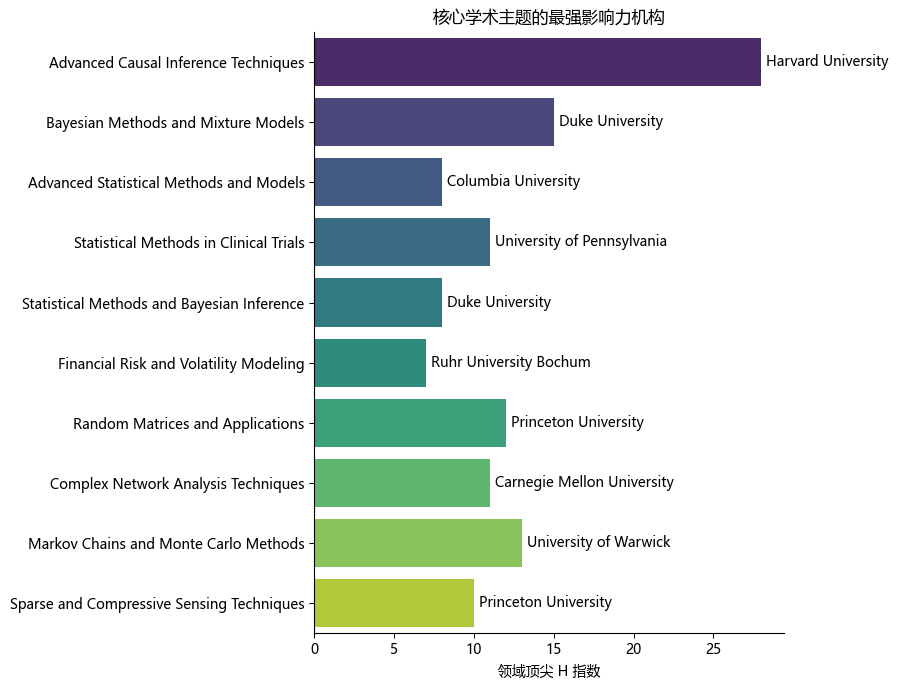

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('stat4_2013_2026_metadata.csv')
# 3. 锁定前 2-11 名主题
top_topics = df['primary_topic'].value_counts().index[1:11]
df_subset = df[df['primary_topic'].isin(top_topics)].copy()

# 4. 拆分机构
df_subset['inst'] = df_subset['institution_names'].str.split('|')
df_exploded = df_subset.explode('inst')
df_exploded['inst'] = df_exploded['inst'].str.strip()

# 5. 定义 H 指数计算函数
def get_h(cites):
    cites = sorted([c for c in cites if pd.notnull(c)], reverse=True)
    return next((i for i, v in enumerate(cites) if v < i + 1), len(cites))

# 6. 计算各领域最强机构
results = []
for topic in top_topics:
    # 筛选当前主题数据
    topic_data = df_exploded[df_exploded['primary_topic'] == topic]
    # 按机构分组计算
    group = topic_data.groupby('inst')['cited_by_count'].apply(list).apply(get_h).reset_index(name='h_index')
    # 获取该领域 H 指数最高的机构
    top_inst = group.sort_values('h_index', ascending=False).iloc[0]
    results.append({
        '学术领域': topic, 
        '主导机构': top_inst['inst'], 
        '领域H指数': top_inst['h_index']
    })
macro_impact_df = pd.DataFrame(results)
print(macro_impact_df)

# 7. 绘图
plt.figure(figsize=(9, 7))
ax = sns.barplot(data=macro_impact_df, x='领域H指数', y='学术领域', palette='viridis', hue='学术领域', legend=False)

# 在条形图旁添加机构名称标注
for i, p in enumerate(ax.patches):
    ax.text(p.get_width() + 0.3, p.get_y() + p.get_height() / 2, 
            macro_impact_df.iloc[i]['主导机构'], va='center', ha='left', fontsize=10)

ax.set(title='核心学术主题的最强影响力机构', xlabel='领域顶尖 H 指数', ylabel='')
sns.despine() # 移除多余边框
plt.tight_layout()
plt.savefig('macro_institution_impact.png', dpi=300, bbox_inches='tight')
plt.show()